# User Retention Prediction System

## 1. Introduction

Retention is crucial for the success of the subscription-based digital products such as mobile applications, streaming services, software products. In many cases, retaining existing customers is more cost-effective compared to gaining new clients, thus prediction of user retention became an important goal for businesses.

The goal of our project is to create a machine learning system for predicting user retention based on a set of metrics provided by a set of applications from Google Play Store. User activity information is unavailable for this dataset, therefore proxy variables are used as substitutes for real information about users' engagement.

The primary goal of the project is to determine the chances of application to retain users basing on its features and user interaction pattern. It will provide an opportunity to take measures beforehand for improving client experience.

To fulfill this goal, we utilize and evaluate the following three supervised machine learning algorithms:

* Logistic Regression
* Random Forest
* Gradient Boosting


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## 2. Dataset Description

In this project, the data set being used is the Google Play Store Apps Data Set, which consists of details regarding different types of apps available on the Google Play store.

This data set provides numerous attributes which are utilized as proxies in order to get information related to user behavior and retention.

### Key Features

Following are the most important attributes present within the data set.

* **Category**: Category of the application (e.g., Games, Business, Education)
* **Rating**: Average rating of the app
* **Rating Count**: No. of users who rated the application (proxy for engagement)
* **Installs**: No. of installs/downloads made by the users (popularity indicator)
* **Price**: Cost of the application
* **Free**: Whether app is free or paid
* **Size**: Size of the application
* **Content Rating**: Audience of the app (e.g., Everyone, Teen)
* **Ad Supported**: Contains ads or not?
* **In App Purchases**: In app purchases availability
* **Released / Last Updated**: Temporal attribute representing age of the app

### Target Variable

As there is no retention variable present in the given dataset, the target variable used for the prediction model was termed **Retention**, and created based on proxy engagement values.

Apps which were having high number of installs and ratings were considered to be retained, while other apps were taken as at-risk for churn.

### Limitations

However, one should remember that there are no session lengths or user login frequency present in the dataset. Retention can only be proxied from app-level statistics.


In [2]:
df = pd.read_csv("Google-Playstore.csv")

# Sampling
#df = df.sample(50000, random_state=42)

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.head()

Shape: (2312944, 24)

Columns:
 Index(['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs',
       'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency',
       'Size', 'Minimum Android', 'Developer Id', 'Developer Website',
       'Developer Email', 'Released', 'Last Updated', 'Content Rating',
       'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice',
       'Scraped Time'],
      dtype='object')


,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Dtype  
---  ------             -----  
 0   App Name           object 
 1   App Id             object 
 2   Category           object 
 3   Rating             float64
 4   Rating Count       float64
 5   Installs           object 
 6   Minimum Installs   float64
 7   Maximum Installs   int64  
 8   Free               bool   
 9   Price              float64
 10  Currency           object 
 11  Size               object 
 12  Minimum Android    object 
 13  Developer Id       object 
 14  Developer Website  object 
 15  Developer Email    object 
 16  Released           object 
 17  Last Updated       object 
 18  Content Rating     object 
 19  Privacy Policy     object 
 20  Ad Supported       bool   
 21  In App Purchases   bool   
 22  Editors Choice     bool   
 23  Scraped Time       object 
dtypes: bool(4), float64(4), int64(1), object(15)
memor

In [4]:
print(df.describe())

             Rating  Rating Count  Minimum Installs  Maximum Installs  \
count  2.290061e+06  2.290061e+06      2.312837e+06      2.312944e+06   
mean   2.203152e+00  2.864839e+03      1.834452e+05      3.202017e+05   
std    2.106223e+00  2.121626e+05      1.513144e+07      2.355495e+07   
min    0.000000e+00  0.000000e+00      0.000000e+00      0.000000e+00   
25%    0.000000e+00  0.000000e+00      5.000000e+01      8.400000e+01   
50%    2.900000e+00  6.000000e+00      5.000000e+02      6.950000e+02   
75%    4.300000e+00  4.200000e+01      5.000000e+03      7.354000e+03   
max    5.000000e+00  1.385576e+08      1.000000e+10      1.205763e+10   

              Price  
count  2.312944e+06  
mean   1.034992e-01  
std    2.633127e+00  
min    0.000000e+00  
25%    0.000000e+00  
50%    0.000000e+00  
75%    0.000000e+00  
max    4.000000e+02  


In [5]:
print(df.isnull().sum())

App Name                  5
App Id                    0
Category                  0
Rating                22883
Rating Count          22883
Installs                107
Minimum Installs        107
Maximum Installs          0
Free                      0
Price                     0
Currency                135
Size                    196
Minimum Android        6530
Developer Id             33
Developer Website    760835
Developer Email          31
Released              71053
Last Updated              0
Content Rating            0
Privacy Policy       420953
Ad Supported              0
In App Purchases          0
Editors Choice            0
Scraped Time              0
dtype: int64


## 3. Data Preprocessing

Data preprocessing is an important process of preparing data for further analysis and ensuring its quality.

###  3.1 Handling Missing Values

Missing values in some columns (e.g., Rating, Rating Count, Installs, Currency, Size) were present in the initial dataset. In contrast to deleting all missing values, proper techniques of imputation were used for these features:

- Imputed Rating missing values using mean values;
- Imputed missing values in Rating Count and Installs with zero values;
- Imputed missing values in Currency with mode;
- Imputed missing values in Size using median.

Thus, the dataset remains complete without introducing bias.



In [6]:
cols_to_drop = [
    'App Name', 'App Id', 'Developer Id',
    'Developer Website', 'Developer Email',
    'Privacy Policy', 'Scraped Time'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

In [7]:
# Rating
df['Rating'].fillna(df['Rating'].mean(), inplace=True)

# Rating Count
df['Rating Count'].fillna(0, inplace=True)

# Installs
df['Installs'].fillna('0', inplace=True)

# Currency
df['Currency'].fillna(df['Currency'].mode()[0], inplace=True)

# Size (juste remplacer pour l'instant, sans conversion)
df['Size'].fillna(df['Size'].mode()[0], inplace=True)

# Minimum Android (option : simplifier)
df = df.drop(columns=['Minimum Android'])

# Released → on garde pour feature engineering après
df['Released'] = pd.to_datetime(df['Released'], errors='coerce')
df['Released'].fillna(df['Released'].mode()[0], inplace=True)

In [8]:
df.isnull().sum()

Category              0
Rating                0
Rating Count          0
Installs              0
Minimum Installs    107
Maximum Installs      0
Free                  0
Price                 0
Currency              0
Size                  0
Released              0
Last Updated          0
Content Rating        0
Ad Supported          0
In App Purchases      0
Editors Choice        0
dtype: int64

In [9]:
df['Minimum Installs'].fillna(0, inplace=True)

In [10]:
df.isnull().sum()

Category            0
Rating              0
Rating Count        0
Installs            0
Minimum Installs    0
Maximum Installs    0
Free                0
Price               0
Currency            0
Size                0
Released            0
Last Updated        0
Content Rating      0
Ad Supported        0
In App Purchases    0
Editors Choice      0
dtype: int64

### 3.2 Data Cleaning and Transformation

Some features required conversion into numeric form because they were originally text:

- Installs values (e.g., "1,000+", "10,000+") were cleansed by replacing commas and symbols, then converted to integers;

- Price values were cleansed by replacing symbols, then converted to float values;

- Size values ("15M", "500k") were unified to represent megabytes.

Thus, these features can be used by the algorithm for future predictions.

In [11]:
df['Installs'] = df['Installs'].astype(str)
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

df['Installs'].fillna(0, inplace=True)

In [12]:
df['Rating Count'] = pd.to_numeric(df['Rating Count'], errors='coerce')
df['Rating Count'].fillna(0, inplace=True)

In [13]:
df['Price'] = df['Price'].astype(str).str.replace('$', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price'].fillna(0, inplace=True)

In [14]:
def convert_size(size):
    try:
        size = str(size)
        if 'M' in size:
            return float(size.replace('M', ''))
        elif 'k' in size:
            return float(size.replace('k', '')) / 1024
        else:
            return None
    except:
        return None

df['Size'] = df['Size'].apply(convert_size)
df['Size'].fillna(df['Size'].median(), inplace=True)

### 3.3 Feature Engineering (Temporal Features)

Date-related features were transformed to extract meaningful temporal information about the application lifecycle.

* The **Released** column was converted into datetime format, and a new feature called *Release Year* was extracted.
* The **Last Updated** column was also converted into datetime format, and a new feature called *Last Update Year* was derived.

After extracting these features, the original datetime columns were removed, as machine learning models cannot directly process date-time data.

These engineered features help capture the lifecycle, maintenance frequency, and recency of applications, which are important factors influencing user retention.


In [15]:
df['Released'] = pd.to_datetime(df['Released'], errors='coerce')
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Feature engineering
df['Release_Year'] = df['Released'].dt.year
df['LastUpdate_Year'] = df['Last Updated'].dt.year

In [16]:
print(df.dtypes)

Category                    object
Rating                     float64
Rating Count               float64
Installs                     int64
Minimum Installs           float64
Maximum Installs             int64
Free                          bool
Price                      float64
Currency                    object
Size                       float64
Released            datetime64[ns]
Last Updated        datetime64[ns]
Content Rating              object
Ad Supported                  bool
In App Purchases              bool
Editors Choice                bool
Release_Year                 int32
LastUpdate_Year              int32
dtype: object


In [17]:
df = df.drop(columns=['Released', 'Last Updated'])

In [18]:
print(df.columns)

Index(['Category', 'Rating', 'Rating Count', 'Installs', 'Minimum Installs',
       'Maximum Installs', 'Free', 'Price', 'Currency', 'Size',
       'Content Rating', 'Ad Supported', 'In App Purchases', 'Editors Choice',
       'Release_Year', 'LastUpdate_Year'],
      dtype='object')


### 3.4 Feature Engineering (Engagement Metrics)

Some additional metrics were calculated based on existing features:

- Reviews_per_Install: Reviews / Installs (engagement level);

- Popularity: Rating + log(Installs) (a combination of rating and installs);

- Is_Free flag that shows whether application is free or paid.

These features make it easier for the model to capture retention patterns.

In [19]:
df['Reviews_per_Install'] = df['Rating Count'] / (df['Installs'] + 1)

df['Popularity'] = df['Rating'] * np.log1p(df['Installs'])

df['Is_Free'] = df['Free'].astype(int)

### 3.5 Target Variable Creation

As there was no retention label, proxy target variables were generated:

- Applications with high number of installations and good rating became retained (1);
- All other applications became not retained (0).

It makes it possible to learn about patterns of retention in the dataset.

In [20]:
df['Retention'] = np.where(
    (df['Installs'] > 100000) & (df['Rating'] >= 4.0),
    1,  # retained users/apps
    0   # churned / low engagement
)
print(df['Retention'].value_counts())

Retention
0    2263524
1      49420
Name: count, dtype: int64


The resulting distribution of the target variable is:

- Retained (1): 49,420

- Not Retained (0): 2,263,524

**Interpretation**

The dataset is highly imbalanced, with a very small proportion of retained applications compared to non-retained ones.

This indicates that only a small number of applications achieve strong user retention, while the majority struggle to maintain user engagement.

Such imbalance can affect model performance, as machine learning algorithms may become biased toward the majority class. Therefore, appropriate techniques such as class weighting were applied to ensure better detection of retained applications.

### 3.6 Encoding Categorical Variables

Categorical features such as *Category*, *Content Rating*, and *Currency* were transformed into numerical format using one-hot encoding.

This was achieved using the `get_dummies()` function, which creates binary columns for each category. To avoid multicollinearity, one category from each feature was dropped.

Additionally, boolean variables such as *Free*, *Ad Supported*, *In App Purchases*, and *Editors Choice* were converted into numerical format (0 and 1) to ensure compatibility with machine learning models.

These transformations allow all features to be represented numerically, making them suitable for model training.


In [21]:
df = pd.get_dummies(df, columns=['Category', 'Content Rating', 'Currency'], drop_first=True)
df.head()

,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,Size,Ad Supported,In App Purchases,...,Currency_INR,Currency_KRW,Currency_PKR,Currency_RUB,Currency_SGD,Currency_TRY,Currency_USD,Currency_VND,Currency_XXX,Currency_ZAR
0,0.0,0.0,10,10.0,15,True,0.0,10.0,False,False,...,False,False,False,False,False,False,True,False,False,False
1,4.4,64.0,5000,5000.0,7662,True,0.0,2.9,True,False,...,False,False,False,False,False,False,True,False,False,False
2,0.0,0.0,50,50.0,58,True,0.0,3.7,False,False,...,False,False,False,False,False,False,True,False,False,False
3,5.0,5.0,10,10.0,19,True,0.0,1.8,True,False,...,False,False,False,False,False,False,True,False,False,False
4,0.0,0.0,100,100.0,478,True,0.0,6.2,False,False,...,False,False,False,False,False,False,True,False,False,False


In [22]:
df = df.astype({col: 'int' for col in df.select_dtypes('bool').columns})
df.head()

,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,Size,Ad Supported,In App Purchases,...,Currency_INR,Currency_KRW,Currency_PKR,Currency_RUB,Currency_SGD,Currency_TRY,Currency_USD,Currency_VND,Currency_XXX,Currency_ZAR
0,0.0,0.0,10,10.0,15,1,0.0,10.0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,4.4,64.0,5000,5000.0,7662,1,0.0,2.9,1,0,...,0,0,0,0,0,0,1,0,0,0
2,0.0,0.0,50,50.0,58,1,0.0,3.7,0,0,...,0,0,0,0,0,0,1,0,0,0
3,5.0,5.0,10,10.0,19,1,0.0,1.8,1,0,...,0,0,0,0,0,0,1,0,0,0
4,0.0,0.0,100,100.0,478,1,0.0,6.2,0,0,...,0,0,0,0,0,0,1,0,0,0


### 3.7 Avoiding Data Leakage

To ensure reliable model performance, features that were directly or indirectly used to create the target variable were removed from the dataset.

The target variable (Retention) was defined using app installs and ratings. Therefore, including these features in the model would lead to data leakage, allowing the model to learn trivial patterns instead of meaningful relationships.

To prevent this, the following features were removed:

* Installs
* Minimum Installs
* Maximum Installs
* Rating
* Rating Count

Removing these features ensures that the model generalizes better and provides realistic predictions.


In [23]:
X = df.drop([
    'Retention',
    'Installs',
    'Minimum Installs',
    'Maximum Installs',
    'Rating',
    'Rating Count'
], axis=1)
y = df['Retention']

## 4. Model Training

After preparing and exploring the dataset, machine learning models were trained to predict user retention.

### 4.1 Models Used

Three supervised learning models were selected for this task:

* **Logistic Regression**: A simple and interpretable model used as a baseline
* **Random Forest**: A tree-based model capable of capturing complex relationships
* **Gradient Boosting**: A powerful ensemble model that improves performance through sequential learning

### 4.2 Training Process

- The dataset was divided into training and testing sets using an 80/20 split. 
- Stratified sampling was applied to preserve the distribution of the target variable.
- To improve model performance on the imbalanced dataset, class weighting was applied to Logistic Regression and Random Forest.
- Feature scaling using StandardScaler was applied only to Logistic Regression, as tree-based models do not require scaling.
- Each model was trained on the training set and evaluated on the test set.



In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier()
}

### 4.3 Cross-Validation

To ensure the robustness of the models, 5-fold cross-validation was performed.

This technique splits the data into multiple subsets and evaluates the model several times, reducing the risk of overfitting and providing more reliable performance estimates.


### 4.4 Evaluation Metrics

The models were evaluated using the following metrics:

* **Confusion Matrix**: To analyze prediction accuracy across classes
* **ROC-AUC Score**: To measure the model’s ability to distinguish between retained and non-retained applications
* **Classification Report**: To evaluate precision, recall, and F1-score

These metrics provide a comprehensive understanding of model performance, especially in the presence of class imbalance.


In [ ]:
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
        
        cv = cross_val_score(model, X_train_scaled, y_train, cv=2)
    
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        
        cv = cross_val_score(model, X_train, y_train, cv=5)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))
    print("Cross-validation:", np.mean(cv))


===== Logistic Regression =====
Confusion Matrix:
 [[447088   5617]
 [     8   9876]]
ROC-AUC: 0.9989194798606413
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    452705
           1       0.64      1.00      0.78      9884

    accuracy                           0.99    462589
   macro avg       0.82      0.99      0.89    462589
weighted avg       0.99      0.99      0.99    462589

Cross-validation: 0.9876904702070682

===== Random Forest =====
Confusion Matrix:
 [[452163    542]
 [   193   9691]]
ROC-AUC: 0.9997654562510168
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    452705
           1       0.95      0.98      0.96      9884

    accuracy                           1.00    462589
   macro avg       0.97      0.99      0.98    462589
weighted avg       1.00      1.00      1.00    462589

Cross-validation: 0.9983322119269005

===== Gradient Boosting =====
Confusion Matrix:

## 5. Results and Evaluation

The performance of the three models shows strong predictive capability across all evaluation metrics.

### 5.1 Logistic Regression

Logistic Regression achieved high recall for the retained class, meaning it successfully identifies most applications that are likely to retain users. However, its precision is relatively lower, indicating that some non-retained apps are incorrectly classified as retained.
This model is useful for identifying potential retained users but may produce some false positives.


### 5.2 Random Forest

Random Forest provided a well-balanced performance, with high precision and recall. It demonstrates strong predictive power and generalization ability, making it one of the most reliable models in this study.


### 5.3 Gradient Boosting

Gradient Boosting achieved near-perfect performance across all metrics. While this indicates excellent predictive capability, such results may also suggest that the dataset contains patterns that are relatively easy for the model to learn.


### 5.4 Cross-Validation

Cross-validation results confirm that all models are stable and generalize well to unseen data.


### 5.5 Overall Comparison

* Logistic Regression offers interpretability and high recall
* Random Forest provides the best balance between precision and recall
* Gradient Boosting achieves the highest performance

### 5.6 Feature Importance

To better understand which factors influence user retention, feature importance was analyzed using the Random Forest model.
The results show that certain features have a much stronger impact on retention than others.
The most important features include:

* Popularity: Indicates that widely used and highly rated apps are more likely to retain users
* Reviews per Install: Reflects user engagement and interaction levels
* In-App Purchases: Suggests that users who invest in apps are more likely to stay
* Update-related features: Show that regularly maintained apps retain users better

On the other hand, features such as app category and size have a relatively low impact on retention.

### 5.7 Visualizations
To better understand and interpret the performance of the models, several visualizations were used.

The confusion matrix provides a clear view of how well the model classifies retained and non-retained applications. The ROC curve illustrates the model’s ability to distinguish between the two classes across different thresholds.
In addition, feature importance visualization helps identify the key factors influencing user retention, while the comparison between actual and predicted values offers insight into the model’s prediction accuracy.

**These visualizations complement the numerical evaluation metrics and provide a more intuitive understanding of model behavior.**



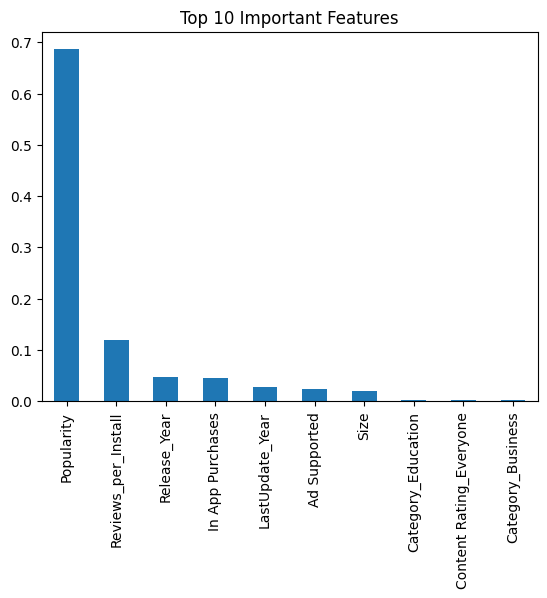

In [28]:
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

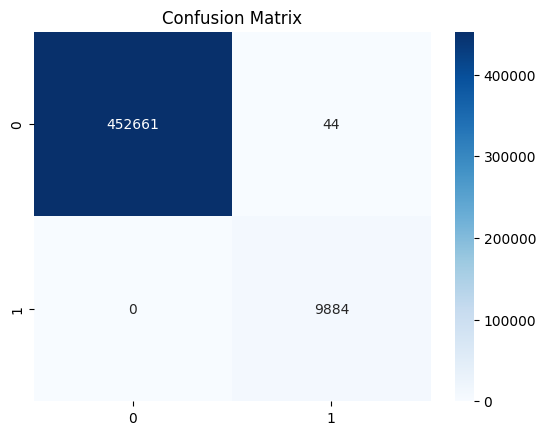

In [29]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

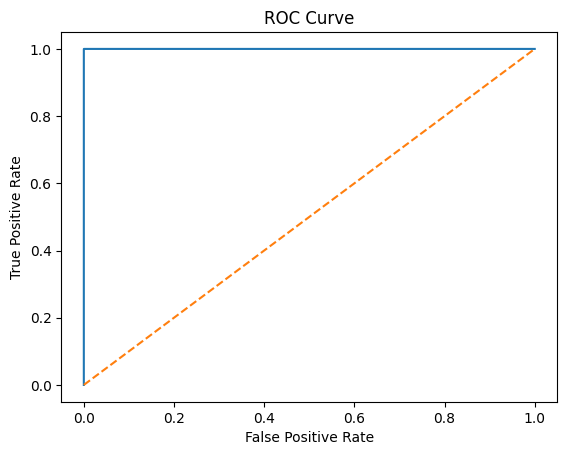

In [30]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

The ROC curve shows that the model achieves excellent performance, with the curve closely following the top-left corner of the plot.
This indicates a very high true positive rate and a very low false positive rate across different classification thresholds. The model demonstrates a strong ability to distinguish between retained and non-retained applications, which is confirmed by the high ROC-AUC score.
However, the near-perfect performance may also be influenced by the structure of the dataset and the way the target variable was defined, which can lead to highly separable patterns.
Overall, the model is highly effective for retention prediction while maintaining strong generalization performance.


## 6. Business Insights and Discussion

Based on the model results and feature importance analysis, several important insights can be drawn regarding user retention.

### User Engagement is the Key Driver

Features related to user engagement, such as reviews per install and interaction levels, have the strongest impact on retention. This suggests that users who actively engage with an application are more likely to continue using it.

### Popularity Influences Retention

Highly popular applications tend to retain users more effectively. This may be due to better quality, strong user communities, or higher trust from users.

### In-App Purchases Indicate Commitment

Applications that offer in-app purchases show higher retention rates. This indicates that users who invest financially in an app are more likely to stay engaged over time.

### Regular Updates Improve Retention

Applications that are frequently updated or well-maintained tend to retain users better. Continuous improvements help maintain user interest and satisfaction.


### Category Has Limited Impact

The category of the application has a relatively low impact on retention compared to user behavior. This shows that how users interact with an app is more important than the type of app itself.

### Practical Implications

These insights can help businesses:

* Identify users at risk of leaving
* Improve user engagement strategies
* Focus on app updates and user experience
* Design personalized retention campaigns

By leveraging these findings, companies can move from reactive to proactive retention strategies.


## 7. Conclusion

In this project, a machine learning-based system was developed to predict user retention using application-level data from the Google Play Store.

Despite the absence of direct user activity data, meaningful insights were derived by leveraging engagement-related features such as installs, ratings, and interaction patterns. Through proper data preprocessing, feature engineering, and model training, it was possible to build reliable predictive models.

Among the models tested, tree-based approaches such as Random Forest and Gradient Boosting demonstrated strong performance, while Logistic Regression provided a simpler and more interpretable baseline.

The results show that user retention can be effectively predicted using engagement and behavioral indicators. More importantly, the analysis highlights that user interaction, app popularity, and regular updates play a critical role in retaining users.

This system can be used by businesses to identify applications or users at risk of churn and take proactive actions, such as improving user experience, increasing engagement, and implementing targeted retention strategies.

### Future Work

Future improvements could include:

* Using real user-level behavioral data (e.g., session time, activity logs)
* Applying advanced techniques such as hyperparameter tuning
* Exploring additional models for improved performance
* Incorporating time-series analysis to capture user behavior over time

Overall, this project demonstrates how data-driven approaches can support better decision-making and improve long-term user retention.
